# 전처리 통합 본 

In [1]:
import pandas as pd 
df = pd.read_csv("data/accepted_2007_to_2018Q4.csv")

# target 생성
status_map = { 
    "Fully Paid" : 0 ,
    "Charged Off" :1, 
    "Default" : 1
}

df["target"] = df["loan_status"].map(status_map)
df = df.loc[df["target"].notnull()].copy()

C:\Users\didwn\AppData\Local\Temp\ipykernel_18868\645983760.py:2: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/accepted_2007_to_2018Q4.csv")
C:\Users\didwn\AppData\Local\Temp\ipykernel_18868\645983760.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target"] = df["loan_status"].map(status_map)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("=" * 60)
print("로드 완료")
print("=" * 60)

로드 완료


## 이상치 처리

In [ ]:

#날짜형 변수 변환 
df['issue_d'] = pd.to_datetime(df['issue_d'])

: 

## 데이터 제거

In [4]:
"""
제거 대상 컬럼 정리 (중복 제거 완료)
"""

drop_columns = [
    # ── 그룹 1: 사후 상환 실적 ──
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',

    # ── 그룹 2: 잔액 사후 정보 ──
    'out_prncp', 'out_prncp_inv',

    # ── 그룹 3: 상각/추심 사후 ──
    'recoveries', 'collection_recovery_fee',

    # ── 그룹 4: 사후 신용 스냅샷 ──
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',

    # ── 그룹 5: Hardship / Settlement ──
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'orig_projected_additional_accrued_interest',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term',

    # ── 그룹 6: 특별 상환 계획 ──
    'pymnt_plan', 'payment_plan_start_date',

    # ── 그룹 7: 승인/집행 결과 ──
    'funded_amnt', 'funded_amnt_inv', 'disbursement_method',

    # ── 그룹 8: 식별자 및 상수 ──
    'id', 'member_id', 'url', 'title', 'zip_code', 'policy_code',

    # ── 그룹 9: 원본 타겟 변수 ──
    'loan_status',

    # ── 그룹 10: 효과 크기 낮은 변수 ── 후보 
    #'initial_list_status', 'total_acc', 'open_acc',
    #'application_type', 'addr_state', 'earliest_cr_line', 'pub_rec',

    # ── 그룹 11: 공동 신청(Joint) 관련 ──
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc',
    'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il',
    'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog',

    # 3차 검토추가 삭제 
    "desc", 

    # 2016년 이후 신규 추가된 세부 신용 리포트 항목 (13개) 
    "open_acc_6m", "open_act_il", "open_il_12m", "open_il_24m","total_bal_il"
    ,"il_util","open_rv_12m","open_rv_24m","max_bal_bc","all_util","inq_fi" 
    ,"total_cu_tl", "inq_last_12m"
]

# 중복 검증
assert len(drop_columns) == len(set(drop_columns)), \
    f"중복 존재: {[c for c in drop_columns if drop_columns.count(c) > 1]}"

print(f"총 제거 대상: {len(drop_columns)}개")

# 실제 적용
df = df.drop(columns=[c for c in drop_columns if c in df.columns])

총 제거 대상: 78개


# 파생 변수 말들기
- 날짜형 

### 차입자 인적 정보 탐색
- 차입자의 고용·소득·거주 정보. 신청 시점의 자기보고 데이터. 

In [107]:
#  emp_title 직함/직업명

# 빈도 기준 상위 N개 추출, 나머지는 'Other'
top_n = 100
top_titles = df['emp_title'].value_counts().head(top_n).index

df['emp_title_grouped'] = df['emp_title'].where(df['emp_title'].isin(top_titles), 'other')
df.loc[df["emp_title_grouped"] == "other", "emp_title_grouped"].value_counts()

# 100개로 줄인다고 한다면 
# other    1,076,627
# [ 만약 사용한다면, 직업이 희긔한 사람들이 부도를 많이 하더라 같은 식으로 사용 가능할지도?
# but 그정도로 가치가 있는가? 

emp_title_grouped
other    1076627
Name: count, dtype: int64

In [108]:
# emp_length 근속 연수
df["emp_length"].isnull().sum()
print(f"결측 수: {df['emp_length'].isnull().sum():,}")
print(f"결측률: {df['emp_length'].isnull().mean():.2%}")

# 5% 정도는 unknown 처리  하자 
df["emp_length"] = df["emp_length"].fillna("unknown")
df["emp_length"].value_counts(normalize=True)*100

결측 수: 78,516
결측률: 5.84%


emp_length
10+ years    32.869439
2 years       9.049764
< 1 year      8.032482
3 years       7.998067
1 year        6.577842
5 years       6.255175
4 years       5.987884
unknown       5.836102
6 years       4.663099
8 years       4.512134
7 years       4.431858
9 years       3.786152
Name: proportion, dtype: float64

In [ ]:
# home_ownership 주거 형태 

# OTHER 로 통합  

df["home_ownership"] = df["home_ownership"].replace(["ANY","NONE"],"OTHER" )

print(df["home_ownership"].value_counts(normalize=True)*100)

print(f"결측 수: {df['home_ownership'].isnull().sum():,}")
print(f"결측률: {df['home_ownership'].isnull().mean():.2%}")

: 

In [16]:
# annual_inc 자기보고 연소득 ($) 
print(f"결측 수: {df['annual_inc'].isnull().sum():,}")
print(f"결측률: {df['annual_inc'].isnull().mean():.2%}")
Q1 = df["annual_inc"].quantile(0.25)
Q3 = df["annual_inc"].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (df["annual_inc"] < Q1 - 1.5 * IQR) | (df["annual_inc"] > Q3 + 1.5 * IQR)
r_o=(outlier_mask.sum()) / len(df["annual_inc"])
print(f"이상치 비율: {r_o *100}")

결측 수: 0
결측률: 0.00%
이상치 비율: 4.896346675586279


In [21]:
# verification_status 소득 검증 상태:  
print(f"결측 수: {df['verification_status'].isnull().sum():,}")
print(f"결측률: {df['verification_status'].isnull().mean():.2%}")

print(df["verification_status"].value_counts(normalize=True)*100)


결측 수: 0
결측률: 0.00%
verification_status
Source Verified    38.747463
Verified           31.096146
Not Verified       30.156391
Name: proportion, dtype: float64


In [25]:
# dti 음수인 행 0으로 채우기 
df["dti"] = df["dti"].where(df["dti"]>=0, 0)

print(f"결측 수: {df['dti'].isnull().sum():,}")
print(f"결측률: {df['dti'].isnull().mean():.2%}")

결측 수: 0
결측률: 0.00%


결측 수: 0
결측률: 0.00%


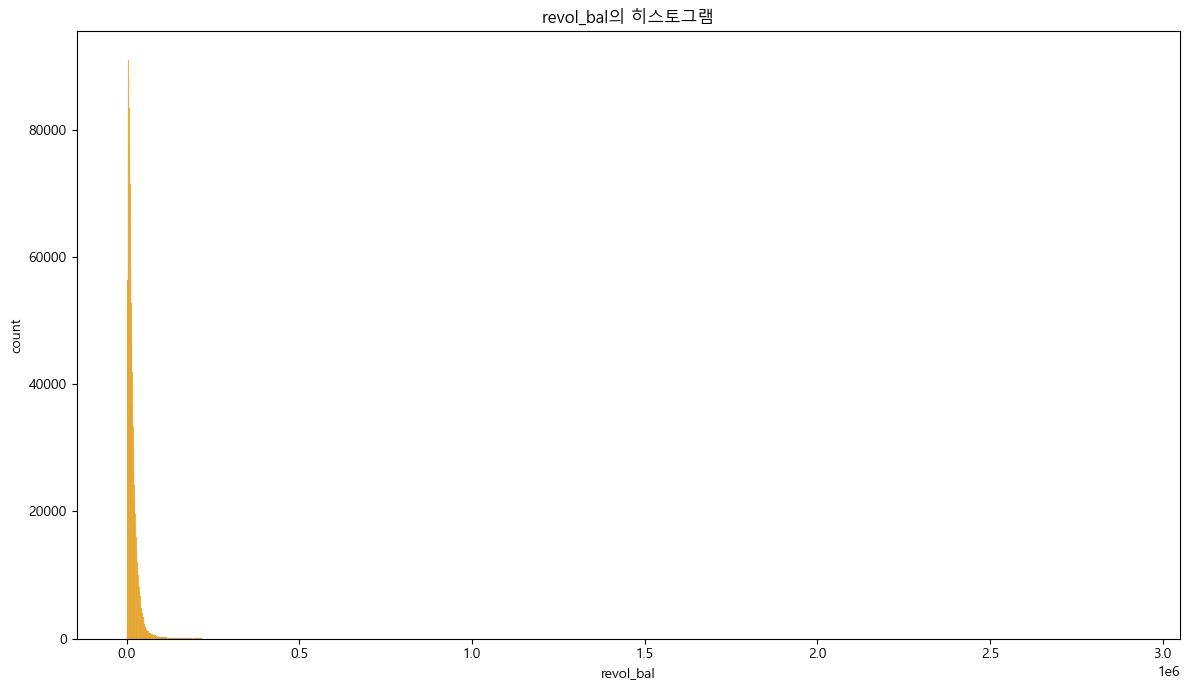

revol_bal
0.0          6564
5235.0        108
6312.0        102
4777.0        101
6118.0        100
5249.0         98
5849.0         98
2.0            98
5453.0         98
8.0            97
5451.0         96
5655.0         96
5389.0         96
5365.0         96
6868.0         96
5729.0         95
5886.0         95
6780.0         95
5891.0         95
10.0           95
7035.0         95
5265.0         95
5271.0         94
8696.0         94
4986.0         94
4643.0         94
8851.0         94
3202.0         93
6001.0         93
5399.0         93
5314.0         93
6497.0         93
4543.0         93
4941.0         93
6462.0         93
5487.0         93
5853.0         93
5997.0         93
6603.0         93
4784.0         93
5754.0         92
6239.0         92
6383.0         92
6406.0         92
6325.0         92
5232.0         92
8533.0         92
3428.0         92
3000.0         92
3804.0         92
6315.0         92
4427.0         92
4989.0         91
5570.0         91
6075.0         91


In [16]:
# revol_bal  리볼빙 총 잔액 ($)
print(f"결측 수: {df['revol_bal'].isnull().sum():,}")
print(f"결측률: {df['revol_bal'].isnull().mean():.2%}")


def hist(df, revol_bal):
    plt.figure(figsize=(12,7))
    sns.histplot(df[revol_bal].dropna(), bins='auto', color='orange')
    plt.ylabel('count')
    plt.xlabel(f'{revol_bal}')
    plt.title(f'{revol_bal}의 히스토그램')
    plt.tight_layout()
    return plt.show()

hist(df,"revol_bal")


print(df["revol_bal"].value_counts())

In [53]:
# revol_util 리볼빙 이용률 (%). 사용액 / 전체 리볼빙 한도
(df["revol_util"]==0).sum() / len(df["revol_util"])  *100
# 결측치 0 으로 채우기 
df["revol_util"] = df["revol_util"].fillna(0)
print(f"결측 수: {df['revol_util'].isnull().sum():,}")
print(f"결측률: {df['revol_util'].isnull().mean():.2%}")

결측 수: 0
결측률: 0.00%


In [ ]:
# total_rev_hi_lim 전체 리볼빙 신용 한도 ($) 

print(f"결측 수: {df['total_rev_hi_lim'].isnull().sum():,}")
print(f"결측률: {df['total_rev_hi_lim'].isnull().mean():.2%}")
total_rev_hi_lim
print((df["total_rev_hi_lim"]==0).sum())


결측 수: 0
결측률: 0.00%
71675


결측 수: 61,145
결측률: 4.54%


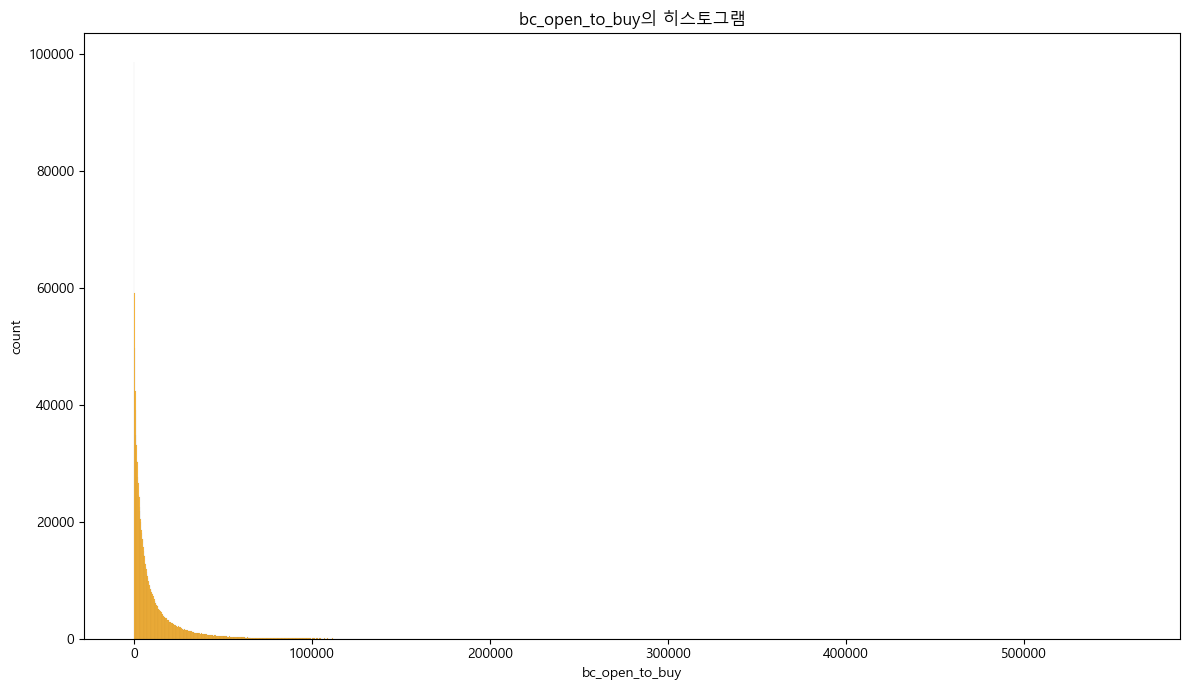

np.float64(1.6066451109376743)

In [130]:
# bc_open_to_buy 뱅크카드 잔여 한도 ($)

print(f"결측 수: {df['bc_open_to_buy'].isnull().sum():,}")
print(f"결측률: {df['bc_open_to_buy'].isnull().mean():.2%}")
df["bc_open_to_buy"].value_counts()

hist(df,"bc_open_to_buy")
(df["bc_open_to_buy"] == 0).sum() / len(df["bc_open_to_buy"]) * 100

결측 수: 61,914
결측률: 4.60%


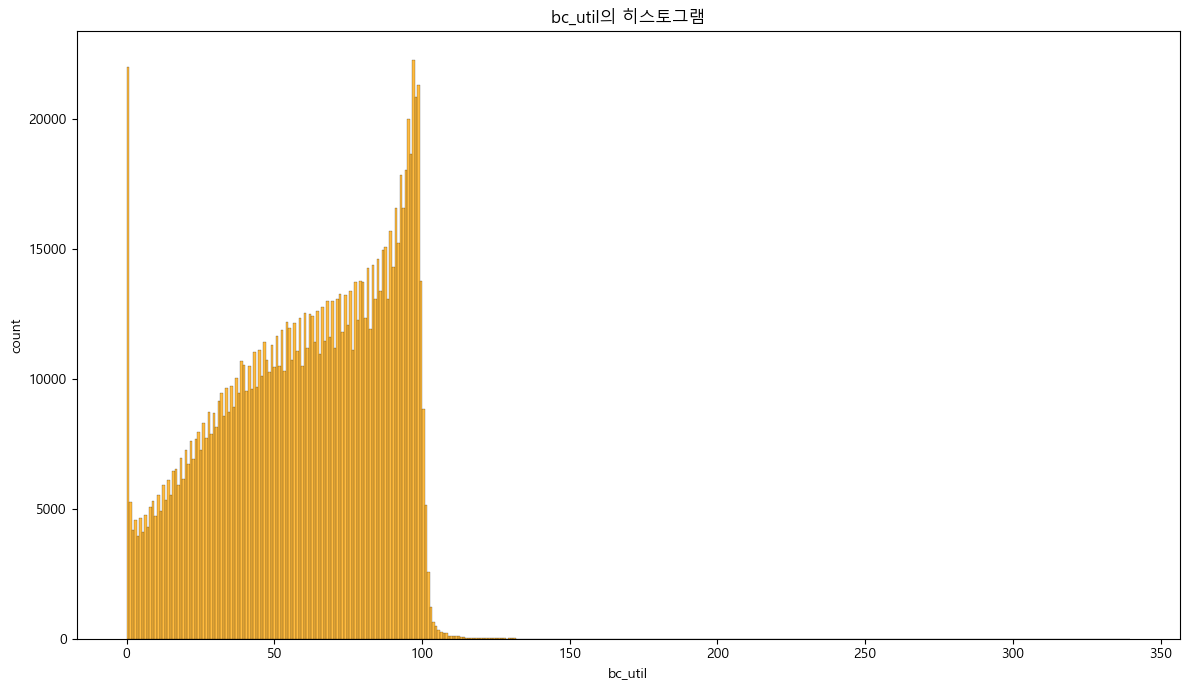

In [131]:
# bc_util 뱅크카드 이용률 (%)
print(f"결측 수: {df['bc_util'].isnull().sum():,}")
print(f"결측률: {df['bc_util'].isnull().mean():.2%}")
df["bc_util"].value_counts()

hist(df,"bc_util")

결측 수: 61,557
결측률: 4.58%


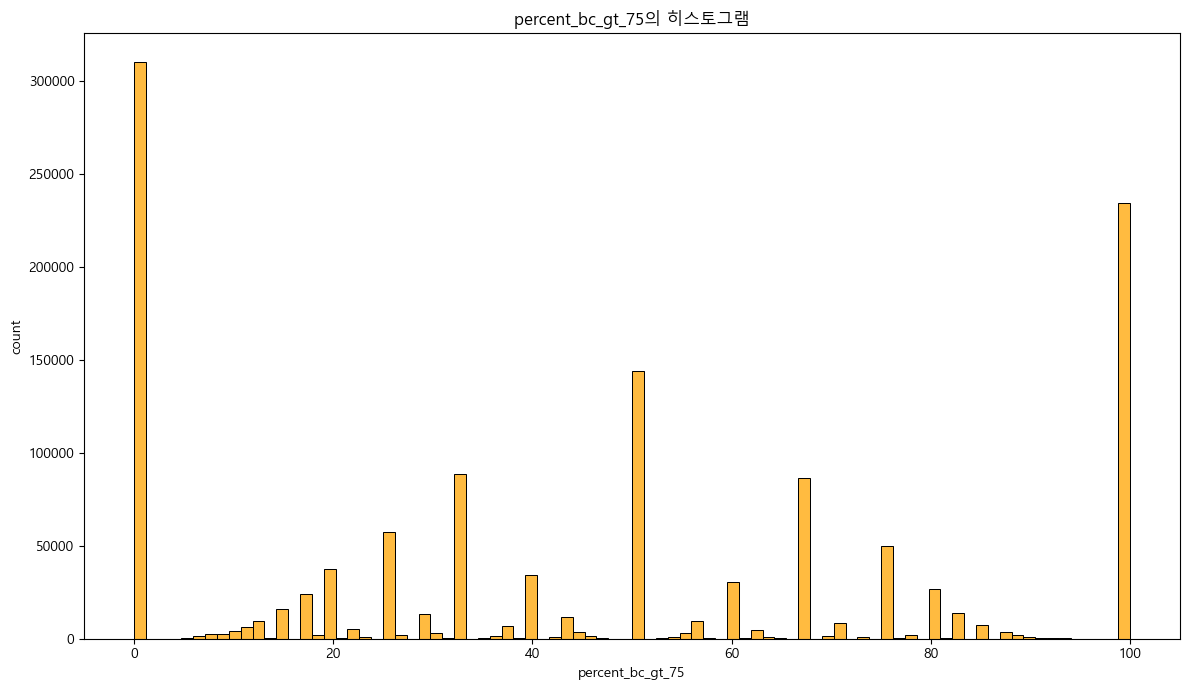

percent_bc_gt_75
0.00      309743
100.00    234696
50.00     143992
33.30      88735
66.70      86220
25.00      57469
75.00      49675
20.00      37336
40.00      34466
60.00      30630
80.00      26666
16.70      24041
14.30      15220
83.30      13915
28.60      13067
42.90      11429
12.50       9746
57.10       9586
71.40       8311
85.70       7081
37.50       6986
11.10       6090
22.20       5107
62.50       4814
10.00       3873
87.50       3476
44.40       3450
55.60       2933
30.00       2661
9.10        2493
77.80       2152
18.20       2001
88.90       1755
8.30        1650
27.30       1590
36.40       1284
70.00       1184
45.50       1072
7.70        1059
90.00        962
54.50        895
15.40        829
63.60        794
72.70        680
41.70        654
7.10         634
81.80        622
23.10        612
30.80        567
90.90        500
6.70         454
38.50        446
21.40        442
58.30        441
13.30        348
46.20        344
91.70        261
61.50        2

In [18]:
# percent_bc_gt_75 뱅크카드 이용률 (%)
print(f"결측 수: {df['percent_bc_gt_75'].isnull().sum():,}")
print(f"결측률: {df['percent_bc_gt_75'].isnull().mean():.2%}")

hist(df,"percent_bc_gt_75")
df["percent_bc_gt_75"].value_counts()

In [27]:
mask = df['total_bc_limit'].isnull()

print(f"num_actv_bc_tl NaN: {mask.sum():,}건")
print(f"그 중 num_actv_bc_tl NaN: {df.loc[mask, 'num_actv_bc_tl'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_actv_bc_tl'].isnull().mean():.1%}")
# percent_bc_gt_75
print(f"\n num_actv_rev_tl NaN: {mask.sum():,}건")
print(f"그 중 num_actv_rev_tl 도 NaN: {df.loc[mask, 'num_actv_rev_tl'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_actv_rev_tl'].isnull().mean():.1%}")
#
print(f"\num_bc_sats NaN: {mask.sum():,}건")
print(f"그 중 num_bc_sats NaN: {df.loc[mask, 'num_bc_sats'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_bc_sats'].isnull().mean():.1%}")



num_actv_bc_tl NaN: 47,281건
그 중 num_actv_bc_tl NaN: 47,281건
동시 NaN 비율: 100.0%

 num_actv_rev_tl NaN: 47,281건
그 중 num_actv_rev_tl 도 NaN: 47,281건
동시 NaN 비율: 100.0%

um_bc_sats NaN: 47,281건
그 중 num_bc_sats NaN: 47,281건
동시 NaN 비율: 100.0%


In [28]:

print(f"\num_bc_tl NaN: {mask.sum():,}건")
print(f"그 중 num_bc_tl NaN: {df.loc[mask, 'num_bc_tl'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_bc_tl'].isnull().mean():.1%}")

print(f"\num_il_tl NaN: {mask.sum():,}건")
print(f"그 중 num_il_tl NaN: {df.loc[mask, 'num_il_tl'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_il_tl'].isnull().mean():.1%}")

print(f"\num_op_rev_tl NaN: {mask.sum():,}건")
print(f"그 중 num_op_rev_tl NaN: {df.loc[mask, 'num_op_rev_tl'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_op_rev_tl'].isnull().mean():.1%}")

print(f"\num_rev_accts NaN: {mask.sum():,}건")
print(f"그 중 num_rev_accts NaN: {df.loc[mask, 'num_rev_accts'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_rev_accts'].isnull().mean():.1%}")

print(f"\num_rev_tl_bal_gt_0 NaN: {mask.sum():,}건")
print(f"그 중 num_rev_tl_bal_gt_0 NaN: {df.loc[mask, 'num_rev_tl_bal_gt_0'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_rev_tl_bal_gt_0'].isnull().mean():.1%}")

print(f"\num_sats NaN: {mask.sum():,}건")
print(f"그 중 numnum_sats_il_tl NaN: {df.loc[mask, 'num_sats'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_sats'].isnull().mean():.1%}")


um_bc_tl NaN: 47,281건
그 중 num_bc_tl NaN: 47,281건
동시 NaN 비율: 100.0%

um_il_tl NaN: 47,281건
그 중 num_il_tl NaN: 47,281건
동시 NaN 비율: 100.0%

um_op_rev_tl NaN: 47,281건
그 중 num_op_rev_tl NaN: 47,281건
동시 NaN 비율: 100.0%

um_rev_accts NaN: 47,281건
그 중 num_rev_accts NaN: 47,281건
동시 NaN 비율: 100.0%

um_rev_tl_bal_gt_0 NaN: 47,281건
그 중 num_rev_tl_bal_gt_0 NaN: 47,281건
동시 NaN 비율: 100.0%

um_sats NaN: 47,281건
그 중 numnum_sats_il_tl NaN: 47,281건
동시 NaN 비율: 100.0%


In [134]:
# 파생컬럼 생성  has_no_bc

df['has_no_bc'] = df['bc_open_to_buy'].isnull().astype(int)     
df['has_no_bc'].value_counts()

has_no_bc
0    1284205
1      61145
Name: count, dtype: int64

In [ ]:
# # 결측값 처리
# df['bc_open_to_buy'] = df['bc_open_to_buy'].fillna(0)
# df['bc_util'] = df['bc_open_to_buy'].fillna(0)

결측 수: 0
결측률: 0.00%


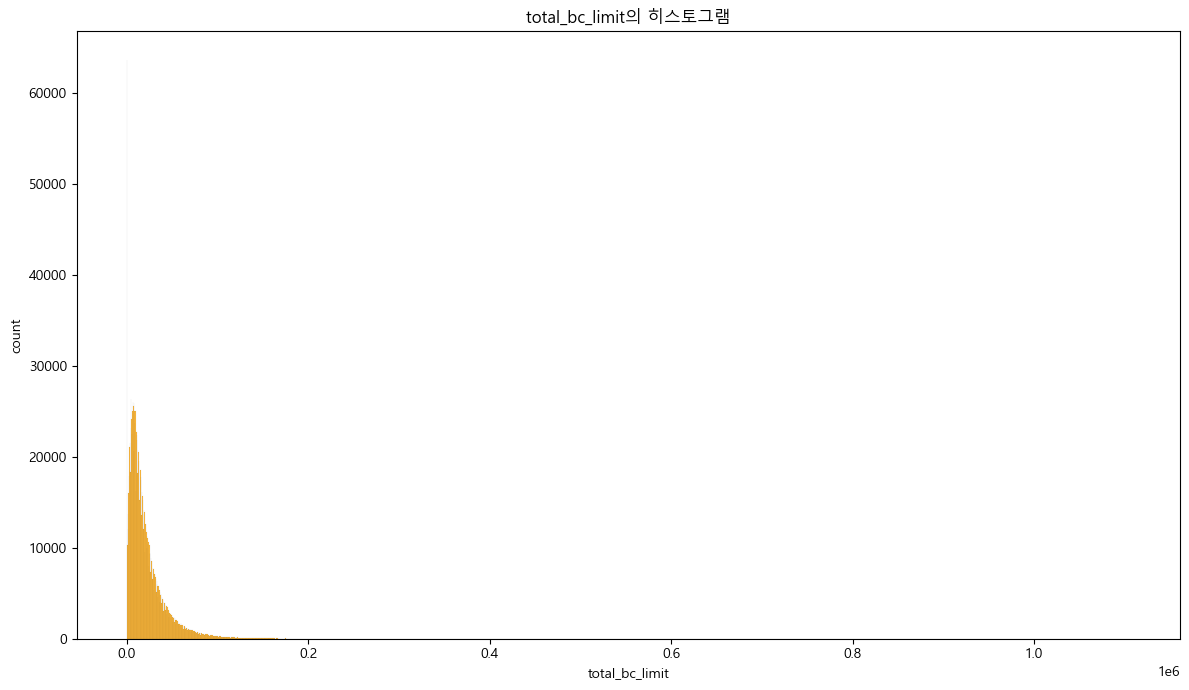

In [139]:
# total_bc_limit
print(f"결측 수: {df['total_bc_limit'].isnull().sum():,}")
print(f"결측률: {df['total_bc_limit'].isnull().mean():.2%}")
df['total_bc_limit'] = df['total_bc_limit'].fillna(0)
hist(df,"total_bc_limit")

In [140]:
# has_no_bc 검증 
mask = df['has_no_bc'] == 1

for col in ['num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats']:
    null_rate = df.loc[mask, col].isnull().mean()
    zero_rate = (df.loc[mask, col] == 0).mean()
    print(f"{col:25s}  NaN: {null_rate:.1%}  |  0: {zero_rate:.1%}")

num_actv_bc_tl             NaN: 77.8%  |  0: 22.2%
num_actv_rev_tl            NaN: 77.8%  |  0: 2.3%
num_bc_sats                NaN: 77.5%  |  0: 20.9%


In [ ]:
# 일반화 함수
def detect_iqr_outliers(series, factor=1.5):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return (series < Q1 - factor * IQR) | (series > Q3 + factor * IQR)

outlier_mask = detect_iqr_outliers(df["col"])
df[outlier_mask]  # 이상치 행 추출

결측 수: 67,527
결측률: 5.02%


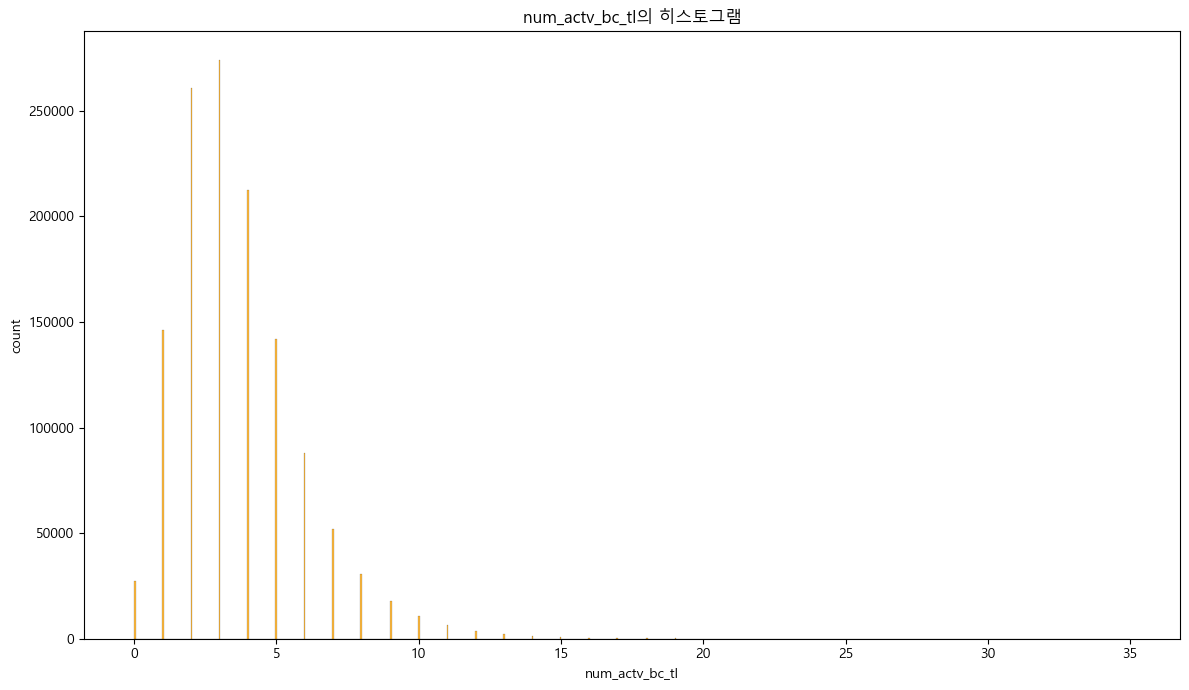

이상치 수: 26648
이상치 %: 1.980748504106738%


In [20]:
#num_actv_bc_tl 활성 뱅크카드 수

print(f"결측 수: {df['num_actv_bc_tl'].isnull().sum():,}")
print(f"결측률: {df['num_actv_bc_tl'].isnull().mean():.2%}")

hist(df,"num_actv_bc_tl")

Q1 = df["num_actv_bc_tl"].quantile(0.25)
Q3 = df["num_actv_bc_tl"].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (df["num_actv_bc_tl"] < Q1 - 1.5 * IQR) | (df["num_actv_bc_tl"] > Q3 + 1.5 * IQR)
ott=  outlier_mask.sum() 
print(f"이상치 수: {outlier_mask.sum()}") 
r= (ott/len(df["num_actv_bc_tl"])) * 100
print(f"이상치 %: {r }%") 



결측 수: 67,527
결측률: 5.02%


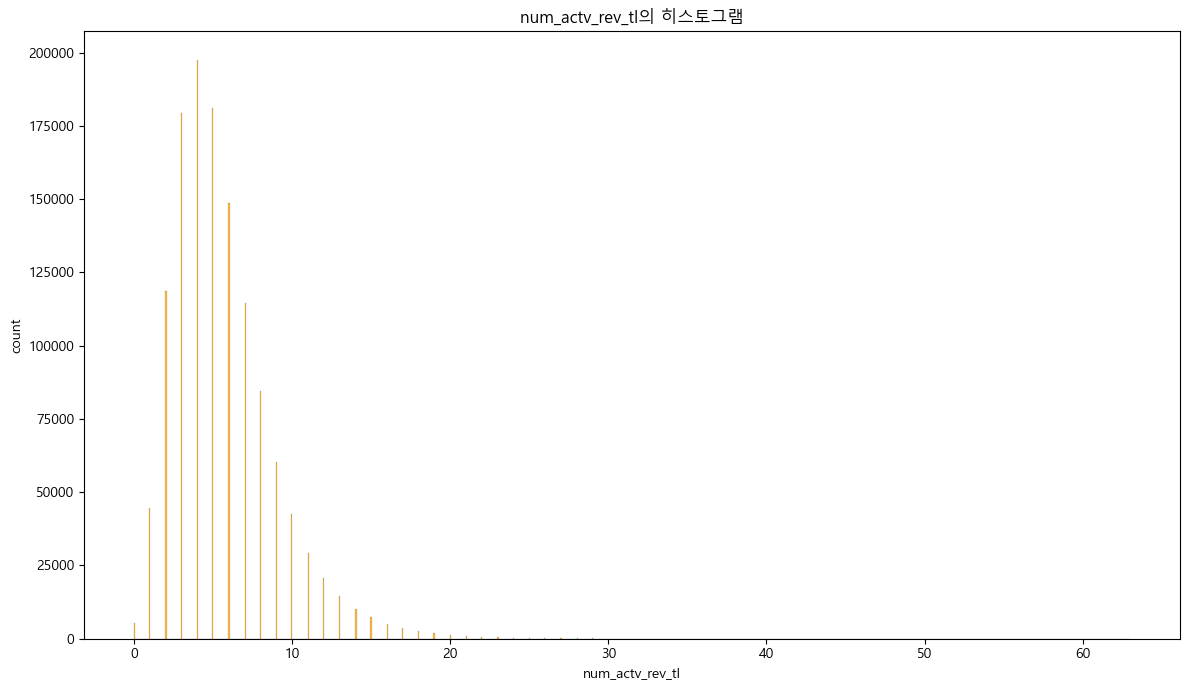

이상치 수: 35970
이상치 %: 2.673653696064221%


In [21]:
#num_actv_rev_tl 활성 리볼빙 계좌 수
print(f"결측 수: {df['num_actv_rev_tl'].isnull().sum():,}")
print(f"결측률: {df['num_actv_rev_tl'].isnull().mean():.2%}")

hist(df,"num_actv_rev_tl")

Q1 = df["num_actv_rev_tl"].quantile(0.25)
Q3 = df["num_actv_rev_tl"].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (df["num_actv_rev_tl"] < Q1 - 1.5 * IQR) | (df["num_actv_rev_tl"] > Q3 + 1.5 * IQR)
ott=  outlier_mask.sum() 
print(f"이상치 수: {outlier_mask.sum()}") 
r= (ott/len(df["num_actv_rev_tl"])) * 100
print(f"이상치 %: {r }%") 

결측 수: 55,841
결측률: 4.15%


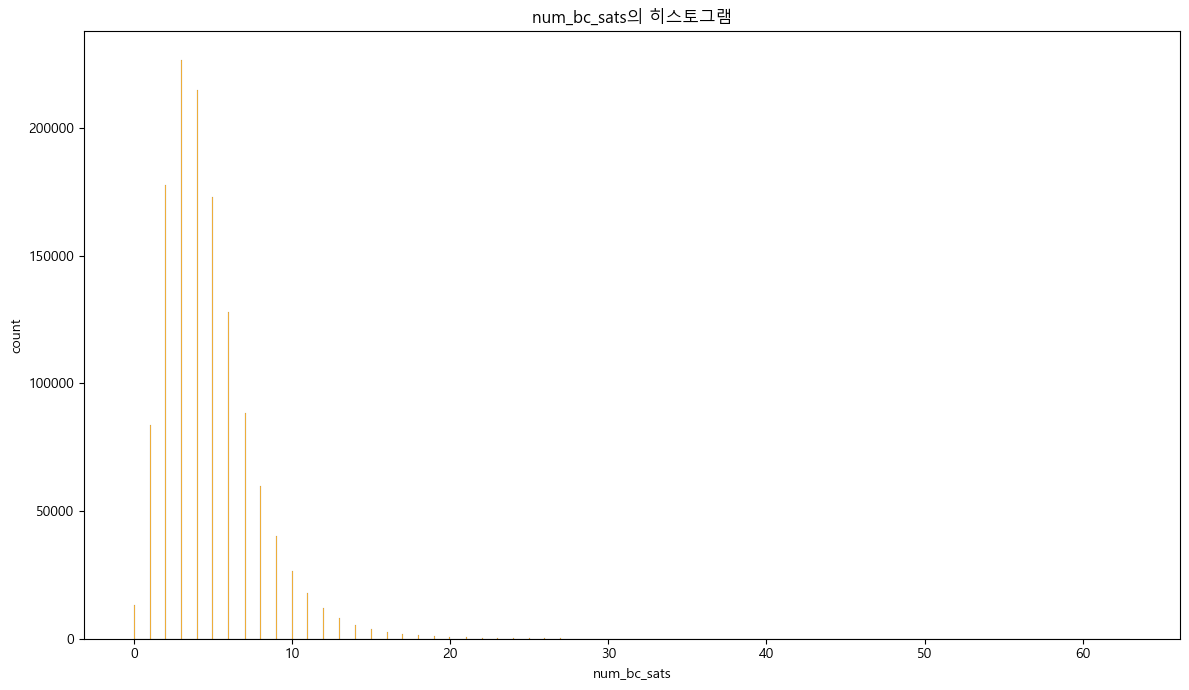

이상치 수: 57213
이상치 %: 4.252648009811573%


In [23]:
#num_bc_sats 양호 상태 뱅크카드 수

print(f"결측 수: {df['num_bc_sats'].isnull().sum():,}")
print(f"결측률: {df['num_bc_sats'].isnull().mean():.2%}")

hist(df,"num_bc_sats")

Q1 = df["num_bc_sats"].quantile(0.25)
Q3 = df["num_bc_sats"].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (df["num_bc_sats"] < Q1 - 1.5 * IQR) | (df["num_bc_sats"] > Q3 + 1.5 * IQR)

ott=  outlier_mask.sum() 
print(f"이상치 수: {outlier_mask.sum()}") 
r= (ott/len(df["num_bc_sats"])) * 100
print(f"이상치 %: {r }%") 

In [148]:
mask = df['num_actv_rev_tl'].isnull()

print(f"num_actv_rev_tl NaN: {mask.sum():,}건")
print(f"그 중 num_actv_bc_tl도 NaN: {df.loc[mask, 'num_actv_bc_tl'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_actv_bc_tl'].isnull().mean():.1%}")

print(f"\n num_actv_rev_tl NaN: {mask.sum():,}건")
print(f"그 중 num_bc_sats 도 NaN: {df.loc[mask, 'num_bc_sats'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'num_bc_sats'].isnull().mean():.1%}")

print(f"\num_actv_rev_tl NaN: {mask.sum():,}건")
print(f"그 중 total_bc_limit NaN: {df.loc[mask, 'total_bc_limit'].isnull().sum():,}건")
print(f"동시 NaN 비율: {df.loc[mask, 'total_bc_limit'].isnull().mean():.1%}")

num_actv_rev_tl NaN: 67,527건
그 중 num_actv_bc_tl도 NaN: 67,527건
동시 NaN 비율: 100.0%

 num_actv_rev_tl NaN: 67,527건
그 중 num_bc_sats 도 NaN: 55,841건
동시 NaN 비율: 82.7%

um_actv_rev_tl NaN: 67,527건
그 중 total_bc_limit NaN: 0건
동시 NaN 비율: 0.0%


In [10]:
mask = df['bc_util'].isnull()

print(f"bc_util NaN: {mask.sum():,}건\n")
print("[bc_util NaN인 행의 grade 분포]")
print(df.loc[mask, 'grade'].value_counts().sort_index())
print()
print("[비율]")
print(df.loc[mask, 'grade'].value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.1%}"))

bc_util NaN: 61,914건

[bc_util NaN인 행의 grade 분포]
grade
A    13672
B    17926
C    13895
D     9228
E     4826
F     1812
G      555
Name: count, dtype: int64

[비율]
grade
A    22.1%
B    29.0%
C    22.4%
D    14.9%
E     7.8%
F     2.9%
G     0.9%
Name: proportion, dtype: str


In [11]:
mask = df['bc_open_to_buy'].isnull()

print(f"bc_open_to_buy NaN: {mask.sum():,}건\n")
print("[bc_open_to_buy NaN인 행의 grade 분포]")
print(df.loc[mask, 'grade'].value_counts().sort_index())
print()
print("[비율]")
print(df.loc[mask, 'grade'].value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.1%}"))

bc_open_to_buy NaN: 61,145건

[bc_open_to_buy NaN인 행의 grade 분포]
grade
A    13554
B    17729
C    13680
D     9086
E     4766
F     1785
G      545
Name: count, dtype: int64

[비율]
grade
A    22.2%
B    29.0%
C    22.4%
D    14.9%
E     7.8%
F     2.9%
G     0.9%
Name: proportion, dtype: str


In [13]:
mask = df['num_actv_bc_tl'].isnull()

print(f"num_actv_bc_tl NaN: {mask.sum():,}건\n")
print("[num_actv_bc_tl NaN인 행의 grade 분포]")
print(df.loc[mask, 'grade'].value_counts().sort_index())
print()
print("[비율]")
print(df.loc[mask, 'grade'].value_counts(normalize=True).sort_index().apply(lambda x: f"{x:.1%}"))

num_actv_bc_tl NaN: 67,527건

[num_actv_bc_tl NaN인 행의 grade 분포]
grade
A    16648
B    21434
C    13916
D     8888
E     4478
F     1697
G      466
Name: count, dtype: int64

[비율]
grade
A    24.7%
B    31.7%
C    20.6%
D    13.2%
E     6.6%
F     2.5%
G     0.7%
Name: proportion, dtype: str


# 수치형 변수형 변수 나누기 

- 범주형: 원핫 인코딩
- 수치형: 스케일 
- 날짜형 

In [ ]:
cat = ["term"]



: 